# Screening results

This notebook summarizes the corpus-screening stage used to identify records that provide evidence of biodiversity change.

## Screening scope and assumptions

- The source corpus contains records returned by the study search-string query.
- Before screening, duplicate records were removed and records with null or empty abstracts were excluded. All remaining records were passed to the screening pipeline; no additional sampling was applied at this stage.
- The preprocessing workflow reduced 2,861,929 source rows to 2,426,808 unique rows, then excluded 12,617 rows with null or empty abstracts. The final screening corpus therefore contains **2,414,191 records**.
- The corpus is stored in `data/partitions` as **242 partitions**. Partitions 1–241 contain 10,000 records each, and partition 242 contains 4,191 records.
- `checklists/mappings/run_names.json` records the 242 run names used by the `labelling` package to associate each partition with its LLM screening run (`partition_1_l0_f1` through `partition_242_l0_f1`).
- The original datasets, normalized request datasets, LLM request payloads, and model outputs form an end-to-end audit trail and can be provided for inspection upon request.
- Screening results are stored under `data/screened-partitions`: `all/screening_all.csv` is the consolidated full output, while the partition-level files under `eligible/` contain records classified as eligible evidence of biodiversity change in this map.

In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def find_repo_root(start: Path = Path.cwd()) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPO_ROOT = find_repo_root()
SCREENING_ALL_PATH = REPO_ROOT / "data" / "screened-partitions" / "all" / "screening_all.csv"
REASON_COLUMNS = ["s1_r", "s2_r", "s3_r", "s4_r"]
STAGE_NAMES = {
    "s1_r": "Q1: biodiversity change",
    "s2_r": "Q2: direction of change",
    "s3_r": "Q3: anthropogenic driver",
    "s4_r": "Q4: driver-change linkage",
}
BIODIVERSITY_GREEN = "#2E7D32"
CONTEXT_GREEN = "#B8CDB2"
PALE_GREEN = "#DCEAD7"
CHARCOAL = "#2B2B2B"
LIGHT_GRAY = "#D9D9D9"

In [34]:
screening_all = pd.read_csv(SCREENING_ALL_PATH, low_memory=False)

## Summary

In [35]:
row_count = len(screening_all)
grain_check_passed = screening_all["UT"].notna().all() and screening_all["UT"].is_unique
columns_text = " , ".join(screening_all.columns)

eligibility_counts = screening_all["eligibility"].value_counts(dropna=False)
eligible_count = int(eligibility_counts.get("ELIGIBLE", 0))
not_eligible_count = int(eligibility_counts.get("NOT_ELIGIBLE", 0))

eligible_mask = screening_all["is_eligible"].eq(True)
unclear_mask = screening_all[REASON_COLUMNS].eq(-1).any(axis=1)
eligible_unclear_count = int((eligible_mask & unclear_mask).sum())
eligible_negative_count = int(
    (eligible_mask & screening_all["s2_dir"].eq("negative")).sum()
)

In [36]:
if grain_check_passed:
    print(f"Grain check passed: all {row_count:,} records have a unique, non-null UT.")
else:
    print(f"Grain check failed for {row_count:,} records: missing or duplicate UT records found.")

print(f"The dataset contains {screening_all.shape[1]} columns: {columns_text}")

print(f"Screening classified {eligible_count:,} records as eligible and {not_eligible_count:,} records as not eligible.")

print(f"Of all eligible records, {eligible_unclear_count:,} were assumed eligible despite at least one unclear screening step.")

print(f"Of all eligible records, {eligible_negative_count:,} report a negative impact on biodiversity.")

Grain check passed: all 2,414,191 records have a unique, non-null UT.
The dataset contains 24 columns: UT , title , authors , abstract , source , publication_year , wos_categories , doi , custom_id , model , created_at , raw_output , pred , s1_r , s2_r , s3_r , s4_r , s1_bio , s2_dir , s3_drivers , s4_link , _source_run , is_eligible , eligibility
Screening classified 605,199 records as eligible and 1,808,992 records as not eligible.
Of all eligible records, 121,707 were assumed eligible despite at least one unclear screening step.
Of all eligible records, 253,081 report a negative impact on biodiversity.


## Reasons for exclusion

The table and diagram show every observed combination of screening steps with a result of `0`. No priority or ordering is assigned to the steps.

In [37]:
ineligible_complete = screening_all.loc[
    ~screening_all["is_eligible"].eq(True)
    & screening_all[REASON_COLUMNS].notna().all(axis=1)
]
zero_steps = ineligible_complete[REASON_COLUMNS].eq(0).rename(columns=STAGE_NAMES)
zero_steps = zero_steps.loc[zero_steps.any(axis=1)]

In [38]:
overlap_table = (
    zero_steps.value_counts()
    .rename("records")
    .reset_index()
    .sort_values("records", ascending=False)
    .reset_index(drop=True)
)
overlap_table.insert(0, "intersection", range(1, len(overlap_table) + 1))
overlap_table["combination"] = overlap_table.apply(
    lambda row: " + ".join(stage for stage in STAGE_NAMES.values() if row[stage]),
    axis=1,
)
overlap_table["percent"] = (overlap_table["records"] / len(zero_steps) * 100).round(2)

(
    overlap_table[["intersection", "combination", "records", "percent"]]
    .style
    .format({"records": "{:,}", "percent": "{:.2f}%"})
    .hide(axis="index")
)

intersection,combination,records,percent
1,Step 1: biodiversity change + Step 2: direction of change + Step 3: anthropogenic driver + Step 4: driver-change linkage,"1,081,249",59.77%
2,Step 1: biodiversity change + Step 2: direction of change + Step 4: driver-change linkage,"435,966",24.10%
3,Step 3: anthropogenic driver + Step 4: driver-change linkage,"217,696",12.03%
4,Step 1: biodiversity change + Step 2: direction of change,"35,857",1.98%
5,Step 4: driver-change linkage,"13,742",0.76%
6,Step 3: anthropogenic driver,"11,332",0.63%
7,Step 1: biodiversity change,"6,645",0.37%
8,Step 1: biodiversity change + Step 3: anthropogenic driver + Step 4: driver-change linkage,"2,913",0.16%
9,Step 1: biodiversity change + Step 4: driver-change linkage,"1,411",0.08%
10,Step 2: direction of change,948,0.05%


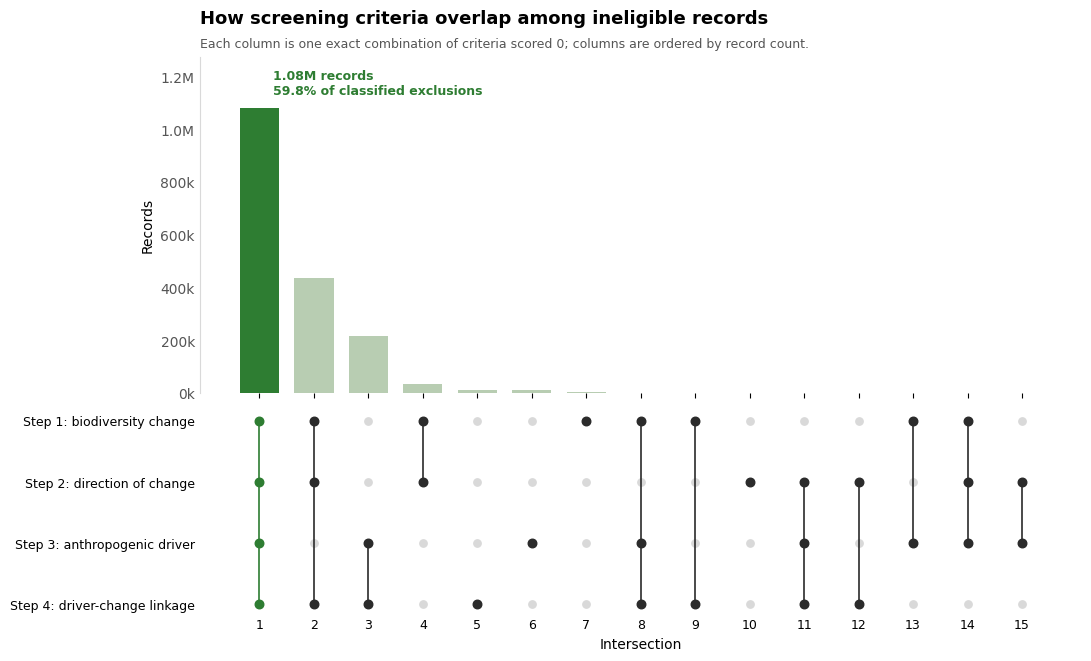

In [39]:
stage_labels = list(STAGE_NAMES.values())
x_positions = range(len(overlap_table))

fig, (count_ax, matrix_ax) = plt.subplots(
    2,
    1,
    figsize=(max(10, len(overlap_table) * 0.72), 6.5),
    sharex=True,
    layout="constrained",
    gridspec_kw={"height_ratios": [3, 1.8], "hspace": 0.03},
)

bar_colors = [BIODIVERSITY_GREEN] + [CONTEXT_GREEN] * (len(overlap_table) - 1)
count_ax.bar(x_positions, overlap_table["records"], color=bar_colors, width=0.72)
count_ax.set_title(
    "How screening criteria overlap among ineligible records",
    loc="left",
    fontsize=13,
    fontweight="bold",
    pad=24,
)
count_ax.text(
    0,
    1.02,
    "Each column is one exact combination of criteria scored 0; columns are ordered by record count.",
    transform=count_ax.transAxes,
    fontsize=9,
    color="#555555",
    va="bottom",
)
count_ax.set_ylabel("Records")
count_ax.yaxis.set_major_formatter(
    lambda value, position: f"{value / 1_000_000:.1f}M" if value >= 1_000_000 else f"{value / 1_000:.0f}k"
)
count_ax.tick_params(axis="y", length=0, colors="#555555")
count_ax.spines[["top", "right", "bottom"]].set_visible(False)
count_ax.spines["left"].set_color(LIGHT_GRAY)

largest = overlap_table.iloc[0]
count_ax.annotate(
    f"{largest['records'] / 1_000_000:.2f}M records\n{largest['percent']:.1f}% of classified exclusions",
    xy=(0, largest["records"]),
    xytext=(10, 8),
    textcoords="offset points",
    color=BIODIVERSITY_GREEN,
    fontsize=9,
    fontweight="bold",
    ha="left",
    va="bottom",
)
count_ax.margins(y=0.18)

for x, row in overlap_table.iterrows():
    active_rows = [i for i, stage in enumerate(stage_labels) if row[stage]]
    active_color = BIODIVERSITY_GREEN if x == 0 else CHARCOAL
    matrix_ax.scatter([x] * len(stage_labels), range(len(stage_labels)), color=LIGHT_GRAY, s=28)
    matrix_ax.scatter([x] * len(active_rows), active_rows, color=active_color, s=38, zorder=3)
    if len(active_rows) > 1:
        matrix_ax.plot(
            [x, x],
            [min(active_rows), max(active_rows)],
            color=active_color,
            linewidth=1.2,
        )

matrix_ax.set_yticks(range(len(stage_labels)), stage_labels)
matrix_ax.set_xticks(list(x_positions), overlap_table["intersection"])
matrix_ax.set_xlabel("Intersection")
matrix_ax.invert_yaxis()
matrix_ax.tick_params(axis="both", length=0, labelsize=9)
matrix_ax.spines[:].set_visible(False)
plt.show()